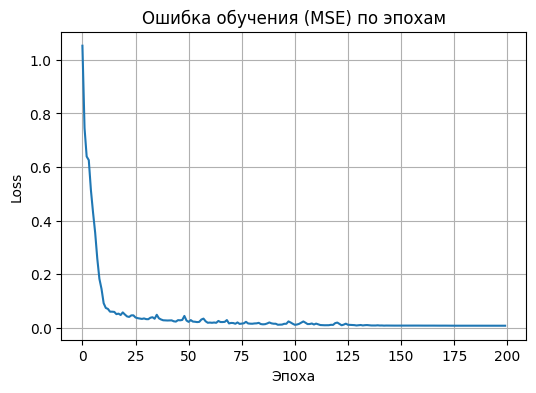

Финальный Loss: 0.0071

Предсказание для x = 1.0: 1.7507 (ожидалось: 1.6829)
✅ Точность выше 90% — УДОВЛЕТВОРИТЕЛЬНО.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
import plotly.offline as pyoff
import plotly.graph_objs as go
import warnings

# отключение ошибок о старой версии функции из библиотеки
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')


K.clear_session()

# Определяем модель (≤2 слоя, ≤50 нейронов)
model = keras.Sequential([
    keras.Input(shape=(1,)),
    keras.layers.Dense(50, activation='tanh'),
    keras.layers.Dense(1, activation='linear')
])

# Компилируем с Adam и MSE
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error'
)

# Целевая функция
def func(x):
    return 2 * np.sin(x)

# Генерируем обучающие данные на одном периоде sin:
raw_xs = np.linspace(-np.pi, np.pi, 200, dtype=np.float32)
xs = raw_xs.reshape(-1, 1)
ys = func(raw_xs).reshape(-1, 1)

# ранняя остановка + снижение LR на плато
early_stop = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=10, min_lr=1e-5)

# Обучаем
history = model.fit(
    xs, ys,
    epochs=200,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop, reduce_lr]
)

# График MSE по эпохам
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.title('Ошибка обучения (MSE) по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid()
plt.show()

# Проверка на x = 1.0
x_val = 1.0
predicted = model.predict(np.array([[x_val]], dtype=np.float32), verbose=0)[0][0]
true_val  = func(x_val)

print(f"Финальный Loss: {model.evaluate(xs, ys, verbose=0):.4f}")
print(f"\nПредсказание для x = {x_val:.1f}: {predicted:.4f} (ожидалось: {true_val:.4f})")
if true_val * 0.9 <= predicted <= true_val * 1.1:
    print("✅ Точность выше 90% — УДОВЛЕТВОРИТЕЛЬНО.")
else:
    print("❌ Точность ниже 90% — НЕ удовлетворительно.")

# Визуализация архитектуры
plot_model(
    model,
    to_file='model_sin_final.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# Сравнение по всей области
x_plot = np.linspace(-np.pi, np.pi, 300, dtype=np.float32)
y_real = func(x_plot)
y_pred  = model.predict(x_plot.reshape(-1,1), verbose=0).flatten()

plot_data = [
    go.Scatter(x=x_plot, y=y_pred, name='Предсказания'),
    go.Scatter(x=x_plot, y=y_real, name='Реальная функция'),
]
layout = go.Layout(
    title='Сравнение Y=2·sin(x) и предсказания нейросети',
    xaxis={'title':'x'},
    yaxis={'title':'Y'}
)
fig = go.Figure(data=plot_data, layout=layout)
pyoff.init_notebook_mode(connected=True)
pyoff.iplot(fig)
